# Workflow di diagnosi data-driven (5 Tappe)
1. Acquisizione dati
### 2. Preprocessamento
### 3. Estrazione feature
4. Addestramento
5. Integrazione

**Ambito di questo notebook: Tappa 2 (Preprocessamento) + Tappa 3 (Estrazione
Feature) — regressione.**
Copre gli step tecnici 3.1 (Selection) -> 3.2 (Cleaning) -> 3.3 (Engineering) -> 3.4 (Formatting/Split) -> 3.5 (Transformation/Scaling).

> Le celle di codice sottostanti non vengono modificate nella loro logica di lettura JSON/Parquet. Le celle Markdown aggiunte mappano ogni blocco al passo del workflow corrispondente e includono una breve legenda dei termini mostrati nei grafici.

## Stato finale confermato (esecuzione completa, post-audit)

| Step | Righe | Colonne | Nota |
|---|---|---|---|
| 3.1 Selection | 742.625 | 9 | Nessuna riga rimossa qui — solo filtro colonne |
| 3.2 Cleaning | 683.025 | 9 | Dedup (59.600 righe) eseguito PRIMA del clipping (bounds: -73.043 / 17.721) |
| 3.3 Engineering | 683.025 | 39 | 2 ratio fisici + 28 interazioni polinomiali, target escluso (no leakage) |
| 3.4 Formatting/Split | 478.117 / 102.454 / 102.454 | 39 (tutte) | Split 70/15/15, schema identico train/test/val |
| 3.5 Transformation/Scaling | 478.117 (train) | 10 di 39 scalate | RobustScaler fit solo su train |

**Obiettivo per la Tappa 4 (Addestramento):** il dataset finale ha 39 colonne, contro le ~11 della
baseline originale (quella che aveva prodotto il runtime di ~20-26h in Fase 4.2). Prima di procedere
con l'addestramento, va decisa esplicitamente quale sottoinsieme di feature alimenta il trainer —
ridurre il numero di feature di input è la leva più diretta per ridurre il tempo di training, più
efficace di un ampliamento della griglia di hyperparameter tuning.

In [1]:
# =============================================================================
# LIBRERIE UTILIZZATE E TOOLKIT DI DATA SCIENCE
# =============================================================================
# Questo blocco definisce l'ambiente per un workflow di Data Engineering e ML.
#
# 1. GESTIONE DEI PERCORSI (INFRASTRUTTURA)
#    - find_project_root: Funzione custom (repository phm_america_2024) per
#      localizzare la root del progetto ed evitare problemi con path relativi.
#
# 2. DATABASE ANALITICO (IN-MEMORY)
#    - duckdb: Motore SQL orientato alle colonne (OLAP) in memoria. Ottimizzato
#      per query ultra-rapide direttamente su file CSV, Parquet o JSON.
#
# 3. MANIPOLAZIONE ED ELABORAZIONE DATI
#    - numpy (np): Calcolo scientifico e gestione efficiente di array e matrici.
#    - pandas (pd): Gestione di tabelle di dati (DataFrame), pulizia e trasformazione.
#    - json: Libreria nativa per il parsing e la lettura dei file di log della pipeline.
#
# 4. DATA VISUALIZATION (REPORTING GRAFICO)
#    - matplotlib.pyplot (plt): Libreria core per la gestione di canvas, figure e layout.
#    - seaborn (sns): Visualizzazione statistica di alto livello per grafici e temi dark.
#
# 5. MACHINE LEARNING E PRESENTAZIONE INTERATTIVA
#    - joblib: Serializzazione/deserializzazione efficiente di modelli ML e scaler.
#    - IPython.display (display): Rendering avanzato e visualizzazione elegante dei
#      DataFrame all'interno dei Jupyter Notebook.
# =============================================================================

In [2]:
import sys
sys.path.append("../../src")
from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import duckdb
from IPython.display import display
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "completo" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase3_data_preparation"


## 3. Estrazione Feature — Data Engineering

Creazione di due feature derivate dal dominio fisico del problema (`mgt_oat_ratio`, `specific_power_index`).

In [ ]:

#-------------------------------------------------------------
#--------------- DATA ENGINEERING (step_3_3_data_engineering)
#-------------------------------------------------------------

**Termini nel grafico:**
- **Kelvin shift**: conversione di `oat` da Celsius a Kelvin (+273.15) per evitare divisioni per zero a 0°C nelle formule dei rapporti.
- **`mgt_oat_ratio`**: rapporto termico tra temperatura interna del gas e temperatura esterna.
- **`specific_power_index`**: indice sintetico di potenza normalizzata, utile come indicatore di degrado meccanico.

Il log indica una predisposizione per interazioni polinomiali di grado 2. **Verificato nella cella successiva**: lo schema reale del Parquet risultante mostra 39 colonne totali (9 originali + 2 ratio fisici + 28 interazioni polinomiali, es. `oat^2`, `oat mgt`, ..., `trq_measured^2`) — le interazioni SONO state generate ed effettivamente presenti in questa esecuzione, coerente con quanto dichiarato nella tabella riassuntiva in cima al notebook.

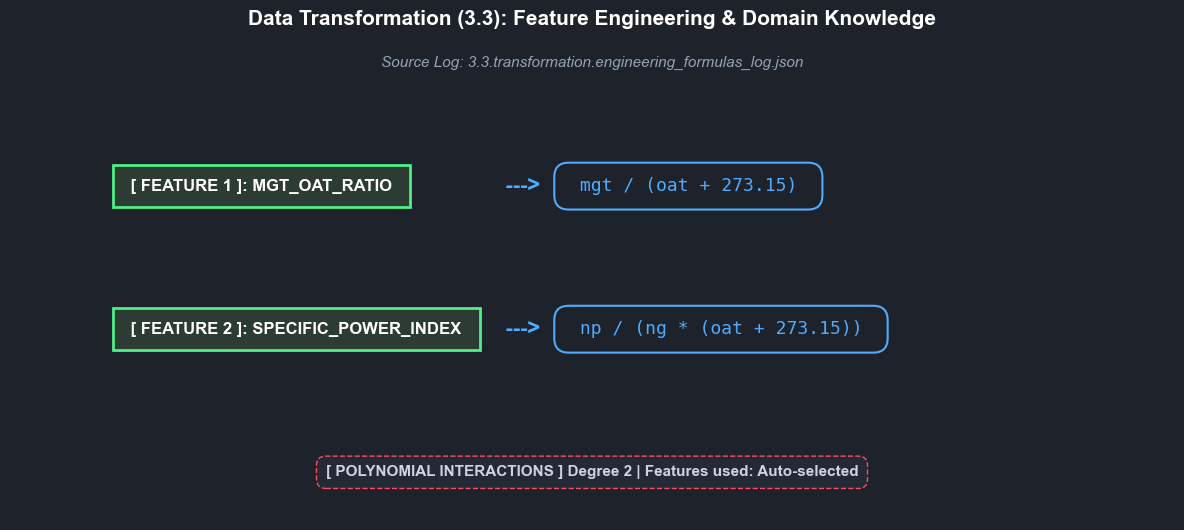


 📊 ANALISI CONCLUSIVA: FEATURE ENGINEERING E DOMAIN KNOWLEDGE (FASE 3.3)
L'analisi del file di log delle trasformazioni matematiche conferma l'applicazione
di tecniche avanzate di 'Feature Engineering' guidate dalla conoscenza di
dominio (Domain Knowledge).

1. CONVERSIONE TERMODINAMICA (KELVIN SHIFT):
   Come si evince dalle equazioni, entrambe le formule applicano un offset
   costante di '+ 273.15' alla variabile 'oat' (Outside Air Temperature).
   Questa è un'operazione fisicamente vitale: converte la temperatura da gradi
   Celsius a scala assoluta Kelvin. Ciò previene matematicamente il rischio
   di 'Zero-Division Error' (divisione per zero a 0°C) e garantisce che i
   rapporti energetici mantengano un senso fisico reale.

2. CREAZIONE DELLE SINTETICHE (ENGINEERED FEATURES):
   - 'mgt_oat_ratio': Rappresenta il rapporto termico tra il gas interno
     misurato (mgt) e l'aria esterna (oat). È un indicatore cruciale
     dell'efficienza del motore. Un rapporto anomalo suggerisce 

In [15]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del file di log delle formule ingegneristiche
filename_formulas = "3.3.transformation.engineering_formulas_log.json"
file_path_formulas = base_phase_path / filename_formulas

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_formulas, "r", encoding="utf-8") as f:
    formulas_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle formule e dei metadati di Feature Engineering

formule_applicate = formulas_data.get("formulas_applied", [])
interazioni = formulas_data.get("interactions", {})
grado_interazione = interazioni.get("degree", 1)

# Logica: Creazione di una lista strutturata per la visualizzazione
lista_formule = []
for f in formule_applicate:
    nome = f.get("name", "N/D")
    espressione = f.get("expression", "N/D")
    lista_formule.append({'Nuova Feature': nome, 'Equazione Matematica': espressione})

df_formule = pd.DataFrame(lista_formule)

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Feature Engineering Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creiamo una figura senza assi tradizionali per fare una "Visual Card"
fig, ax = plt.subplots(figsize=(12, 5.5), facecolor='#1e222b')
ax.set_facecolor('#242936')
ax.axis('off') # Nascondiamo gli assi perché disegneremo dei pannelli di testo

# Titolo Principale
fig.suptitle("Data Transformation (3.3): Feature Engineering & Domain Knowledge",
             fontsize=15, fontweight='bold', color='white', y=0.96)
ax.text(0.5, 0.95, f"Source Log: {filename_formulas}",
        fontsize=11, style='italic', color='#94a3b8', ha='center', transform=ax.transAxes)

# Disegno dei pannelli delle formule (Cards)
y_pos = 0.70
for i, row in df_formule.iterrows():
    # Box per il nome della nuova feature (Verde/Ciano) - EMOJI RIMOSSI
    props_name = dict(boxstyle="square,pad=0.8", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=2)
    ax.text(0.1, y_pos, f" [ FEATURE {i+1} ]: {row['Nuova Feature'].upper()} ",
            fontsize=12, fontweight='bold', color="white", va="center", bbox=props_name)

    # Freccia direzionale in formato ASCII
    ax.text(0.42, y_pos, " ---> ", fontsize=16, fontweight='bold', color="#4facfe", va="center")

    # Box per l'equazione (Sfondo scuro, testo azzurro)
    props_eq = dict(boxstyle="round,pad=0.8", facecolor="#1e222b", edgecolor="#4facfe", linewidth=1.5)
    ax.text(0.48, y_pos, f" {row['Equazione Matematica']} ",
            fontsize=13, family='monospace', color="#4facfe", va="center", bbox=props_eq)

    y_pos -= 0.30

# Box informativo sulle Interazioni Polinomiali (in basso) - EMOJI RIMOSSI
props_interact = dict(boxstyle="round,pad=0.6", facecolor="#242936", edgecolor="#ff4b5c", linestyle="--")
testo_interact = f"[ POLYNOMIAL INTERACTIONS ] Degree {grado_interazione} | Features used: Auto-selected"
ax.text(0.5, 0.10, testo_interact, fontsize=11, fontweight='bold', color="#cbd5e1",
        va="center", ha="center", bbox=props_interact)

plt.tight_layout()
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

analisi_feature_engineering = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: FEATURE ENGINEERING E DOMAIN KNOWLEDGE (FASE 3.3)
================================================================================
L'analisi del file di log delle trasformazioni matematiche conferma l'applicazione
di tecniche avanzate di 'Feature Engineering' guidate dalla conoscenza di
dominio (Domain Knowledge).

1. CONVERSIONE TERMODINAMICA (KELVIN SHIFT):
   Come si evince dalle equazioni, entrambe le formule applicano un offset
   costante di '+ 273.15' alla variabile 'oat' (Outside Air Temperature).
   Questa è un'operazione fisicamente vitale: converte la temperatura da gradi
   Celsius a scala assoluta Kelvin. Ciò previene matematicamente il rischio
   di 'Zero-Division Error' (divisione per zero a 0°C) e garantisce che i
   rapporti energetici mantengano un senso fisico reale.

2. CREAZIONE DELLE SINTETICHE (ENGINEERED FEATURES):
   - 'mgt_oat_ratio': Rappresenta il rapporto termico tra il gas interno
     misurato (mgt) e l'aria esterna (oat). È un indicatore cruciale
     dell'efficienza del motore. Un rapporto anomalo suggerisce che il motore
     sta dissipando troppo calore per mantenere le prestazioni nominali.
   - 'specific_power_index': Normalizza la potenza erogata dalla turbina (np)
     rispetto alla velocità del generatore di gas (ng) e alla densità dell'aria
     (influenzata dalla OAT). Costituisce una metrica sintetica eccellente
     per valutare lo stato di degrado meccanico (Health Indicator).

3. INTERAZIONI POLINOMIALI (POLYNOMIAL FEATURES):
   Il log indica la predisposizione per la generazione di features polinomiali
   di grado {grado_interazione}. Questo passaggio permetterà ai modelli lineari di
   catturare relazioni non lineari complesse tra i sensori, aumentando il
   potere predittivo del sistema senza l'uso obbligatorio di reti neurali profonde.
================================================================================
"""
print(analisi_feature_engineering)

In [16]:
path_x_y_train_3_3 = base_run_dir / "phase3_data_preparation" / ("3.3.transformation.transformed_regression_train.parquet")

query_conteos = f"""
SELECT 'path_x_y_train_3_3' as dataset, count(*) as record_totali FROM parquet_scan
('{path_x_y_train_3_3}')
"""
print(duckdb.query(query_conteos).to_df())
print("----------------------------------------------------")
query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_3}')"
print("--- ESTRUCTURA DATASET DE path_x_y_train_3_3 ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_3}' LIMIT 3"
df_duck = con.sql(query).df()
display(df_duck)

              dataset  record_totali
0  path_x_y_train_3_3         683025
----------------------------------------------------
--- ESTRUCTURA DATASET DE path_x_y_train_3_3 ---
             column_name column_type
0                    oat      DOUBLE
1                    mgt      DOUBLE
2                     pa      DOUBLE
3                    ias      DOUBLE
4                     np      DOUBLE
5                     ng      DOUBLE
6           trq_measured      DOUBLE
7                 faulty      BIGINT
8             trq_margin      DOUBLE
9          mgt_oat_ratio      DOUBLE
10  specific_power_index      DOUBLE
11                 oat^2      DOUBLE
12               oat mgt      DOUBLE
13                oat pa      DOUBLE
14               oat ias      DOUBLE
15                oat np      DOUBLE
16                oat ng      DOUBLE
17      oat trq_measured      DOUBLE
18                 mgt^2      DOUBLE
19                mgt pa      DOUBLE
20               mgt ias      DOUBLE
21        

,oat,mgt,pa,ias,np,ng,trq_measured,faulty,trq_margin,mgt_oat_ratio,...,ias^2,ias np,ias ng,ias trq_measured,np^2,np ng,np trq_measured,ng^2,ng trq_measured,trq_measured^2
0,18.75,643.6,1091.7940,91.3125,100.39,96.44,73.8,0,-2.561291,2.204865,...,8337.972656,9166.861875,8806.1775,6738.8625,10078.1521,9681.6116,7408.782,9300.6736,7117.272,5446.44
1,19.25,566.7,133.5024,25.6250,99.56,90.36,52.9,1,-0.921909,1.938098,...,656.640625,2551.225000,2315.4750,1355.5625,9912.1936,8996.2416,5266.724,8164.9296,4780.044,2798.41
2,15.75,571.8,933.9072,119.0000,99.97,91.48,54.8,1,-2.705606,1.979232,...,14161.000000,11896.430000,10886.1200,6521.2000,9994.0009,9145.2556,5478.356,8368.5904,5013.104,3003.04


## 3. Estrazione Feature (cont.) — Data Formatting

Suddivisione del dataset in Training / Validation / Test e preparazione del manifest per l'addestramento.

In [17]:
#-------------------------------------------------------------
# --------------- DATA FORMATTING (step_3_4_data_formatting)
#-------------------------------------------------------------

**Termini nel grafico:**
- **`random_state`**: seme fisso che garantisce che lo split casuale sia riproducibile — cioè che rieseguendo il codice si ottenga sempre la stessa suddivisione.
- **`to_numpy_applied`**: indica se i dati sono stati convertiti in array NumPy (`False` = mantenuti come DataFrame/Parquet, utile per conservare i nomi delle feature).

Osservazione: il file di trace (`split_indices_trace.json`) contiene solo `train_shape`, `val_shape`, `test_shape` e `random_state` — non è presente alcuna chiave relativa a un raggruppamento per pseudo-motore (GMM). Vale la pena verificare se questo è coerente con la strategia di split pianificata per il progetto, dato che uno split raggruppato per asset è generalmente preferibile a uno split puramente casuale per riga quando l'obiettivo è generalizzare su nuovi motori.

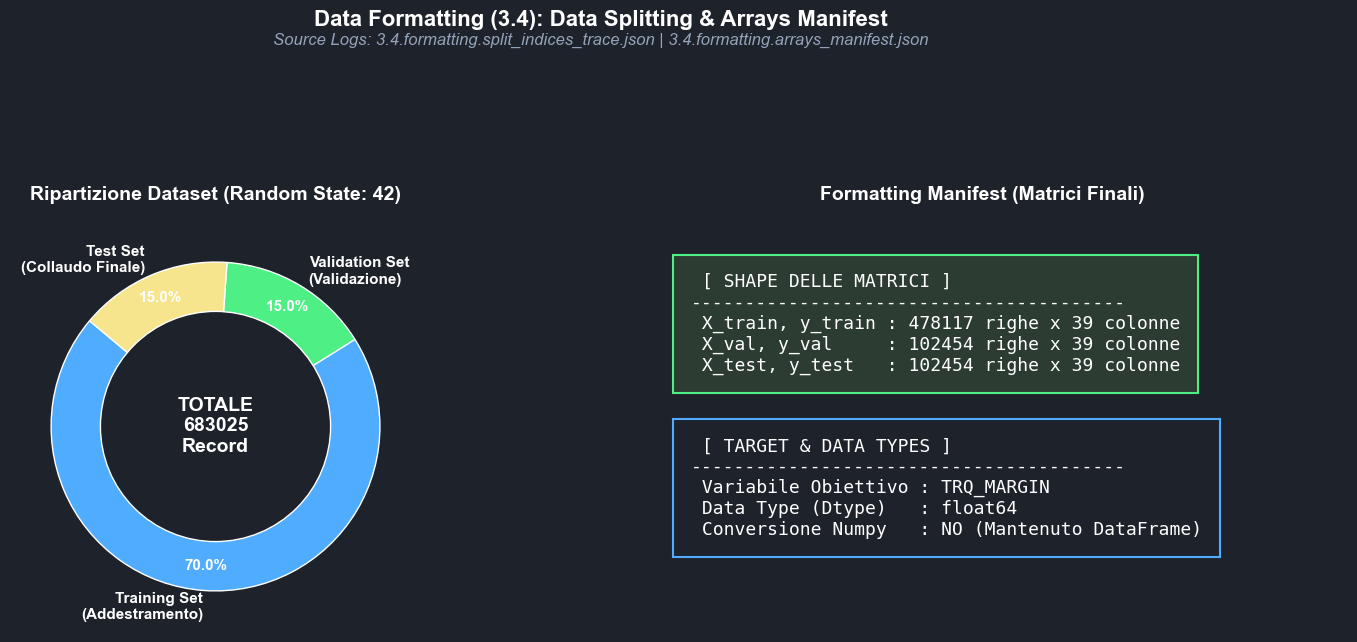


 📊 ANALISI CONCLUSIVA: DATA SPLITTING & ARRAYS MANIFEST (FASE 3.5)
L'analisi dei file di formattazione finalizza la Fase di Data Preparation,
certificando che i dati sono strutturalmente pronti per essere elaborati
dai modelli di Machine Learning.

1. DATA SPLITTING (RIPARTIZIONE DEI DATI):
   Il dataset originario pulito (composto da 683025 record) è stato
   suddiviso in tre partizioni isolate:
   - Training Set (478117 record, ~70%): Verrà utilizzato per l'addestramento
     e l'ottimizzazione dei pesi del modello.
   - Validation Set (102454 record, ~15%): Un set isolato fondamentale per
     l'Hyperparameter Tuning e per implementare logiche di 'Early Stopping',
     prevenendo l'Overfitting (sovradattamento) durante il training.
   - Test Set (102454 record, ~15%): Completamente "cieco" al modello,
     verrà usato esclusivamente nella Fase 5 per valutare oggettivamente le
     performance di generalizzazione in un contesto di produzione reale.
   L'utilizzo di un seme casuale (

In [18]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica dei file di log della Fase 3.5
filename_split = "3.4.formatting.split_indices_trace.json"
filename_manifest = "3.4.formatting.arrays_manifest.json"

file_path_split = base_phase_path / filename_split
file_path_manifest = base_phase_path / filename_manifest

# Lettura dinamica dei file JSON (L'INPUT ENTRA QUI)
with open(file_path_split, "r", encoding="utf-8") as f:
    split_data = json.load(f)

with open(file_path_manifest, "r", encoding="utf-8") as f:
    manifest_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione delle metriche di Splitting
train_shape = split_data["train_shape"]
val_shape = split_data["val_shape"]
test_shape = split_data["test_shape"]
random_state = split_data["random_state"]

# Logica: Preparazione dei dati per il grafico a torta/ciambella
volumi_partizioni = [train_shape[0], val_shape[0], test_shape[0]]
etichette_partizioni = ['Training Set\n(Addestramento)', 'Validation Set\n(Validazione)', 'Test Set\n(Collaudo Finale)']
colori_partizioni = ['#4facfe', '#4ef085', '#f6e58d']

# Estrazione delle metriche del Manifest
target_col = manifest_data["target_col"]
target_dtype = manifest_data["target_dtype"]
numpy_status = "SI" if manifest_data["to_numpy_applied"] else "NO (Mantenuto DataFrame)"

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Splitting & Manifest Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione figura: 1 riga, 2 colonne
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO (Source Logs)
fig.suptitle("Data Formatting (3.4): Data Splitting & Arrays Manifest",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.91, f"Source Logs: {filename_split} | {filename_manifest}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Donut Chart per il Data Splitting ---
ax1 = axes[0]
ax1.set_facecolor('#1e222b') # Sfondo scuro unificato per la torta

# Generazione della torta (con un cerchio al centro per farla diventare una ciambella)
wedges, texts, autotexts = ax1.pie(volumi_partizioni, labels=etichette_partizioni, colors=colori_partizioni,
                                   autopct='%1.1f%%', startangle=140, pctdistance=0.85,
                                   textprops=dict(color="white", fontsize=11, fontweight='bold'))

# Disegno del cerchio interno (Donut Hole)
centro_ciambella = plt.Circle((0, 0), 0.70, fc='#1e222b')
ax1.add_artist(centro_ciambella)

# Testo al centro della ciambella
totale_righe = sum(volumi_partizioni)
ax1.text(0, 0, f"TOTALE\n{totale_righe}\nRecord", ha='center', va='center', fontsize=14, fontweight='bold', color='white')
ax1.set_title(f"Ripartizione Dataset (Random State: {random_state})", fontsize=14, fontweight='bold', color='white', pad=15)

# --- GRAFICO B: Manifest Card (Pannello di Testo) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')
ax2.axis('off') # Nascondiamo gli assi per usare l'area come una scheda visiva

ax2.set_title("Formatting Manifest (Matrici Finali)", fontsize=14, fontweight='bold', color='white', pad=15)

# Pannello per le dimensioni delle matrici
testo_matrici = (
    f" [ SHAPE DELLE MATRICI ] \n"
    f"----------------------------------------\n"
    f" X_train, y_train : {train_shape[0]} righe x {train_shape[1]} colonne\n"
    f" X_val, y_val     : {val_shape[0]} righe x {val_shape[1]} colonne\n"
    f" X_test, y_test   : {test_shape[0]} righe x {test_shape[1]} colonne"
)
props_matrici = dict(boxstyle="square,pad=1", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=1.5)
ax2.text(0.1, 0.75, testo_matrici, fontsize=13, family='monospace', color="white", va="center", bbox=props_matrici)

# Pannello per i Dtype e il Target
testo_target = (
    f" [ TARGET & DATA TYPES ] \n"
    f"----------------------------------------\n"
    f" Variabile Obiettivo : {target_col.upper()}\n"
    f" Data Type (Dtype)   : {target_dtype}\n"
    f" Conversione Numpy   : {numpy_status}"
)
props_target = dict(boxstyle="square,pad=1", facecolor="#1e222b", edgecolor="#4facfe", linewidth=1.5)
ax2.text(0.1, 0.35, testo_target, fontsize=13, family='monospace', color="white", va="center", bbox=props_target)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

analisi_formatting = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: DATA SPLITTING & ARRAYS MANIFEST (FASE 3.5)
================================================================================
L'analisi dei file di formattazione finalizza la Fase di Data Preparation,
certificando che i dati sono strutturalmente pronti per essere elaborati
dai modelli di Machine Learning.

1. DATA SPLITTING (RIPARTIZIONE DEI DATI):
   Il dataset originario pulito (composto da {totale_righe} record) è stato
   suddiviso in tre partizioni isolate:
   - Training Set ({train_shape[0]} record, ~70%): Verrà utilizzato per l'addestramento
     e l'ottimizzazione dei pesi del modello.
   - Validation Set ({val_shape[0]} record, ~15%): Un set isolato fondamentale per
     l'Hyperparameter Tuning e per implementare logiche di 'Early Stopping',
     prevenendo l'Overfitting (sovradattamento) durante il training.
   - Test Set ({test_shape[0]} record, ~15%): Completamente "cieco" al modello,
     verrà usato esclusivamente nella Fase 5 per valutare oggettivamente le
     performance di generalizzazione in un contesto di produzione reale.
   L'utilizzo di un seme casuale ('Random State' = {random_state}) garantisce
   la totale riproducibilità scientifica dell'esperimento.

2. FORMATTING MANIFEST (ARCHITETTURA DEI TENSORI):
   Il manifest conferma che il bersaglio predittivo è '{target_col}' ed è stato
   formattato rigorosamente in '{target_dtype}' (condizione necessaria per la
   Loss Function nella Regressione).
   Inoltre, il flag 'to_numpy_applied': {manifest_data['to_numpy_applied']} indica che i
   dati mantengono la struttura tabellare di Pandas/Parquet. Questa è un'ottima
   scelta di design: permette ai modelli avanzati (come NGBoost o XGBoost) di
   preservare l'interpretabilità, conservando i nomi originari delle features
   per generare accuratamente la 'Feature Importance' nella fase finale.
================================================================================
"""
print(analisi_formatting)

**Termini nel grafico:**
- **Hexbin plot**: variante dello scatter plot che raggruppa i punti in esagoni colorati in base alla densità — utile con centinaia di migliaia di righe, dove un normale scatter sarebbe illeggibile.

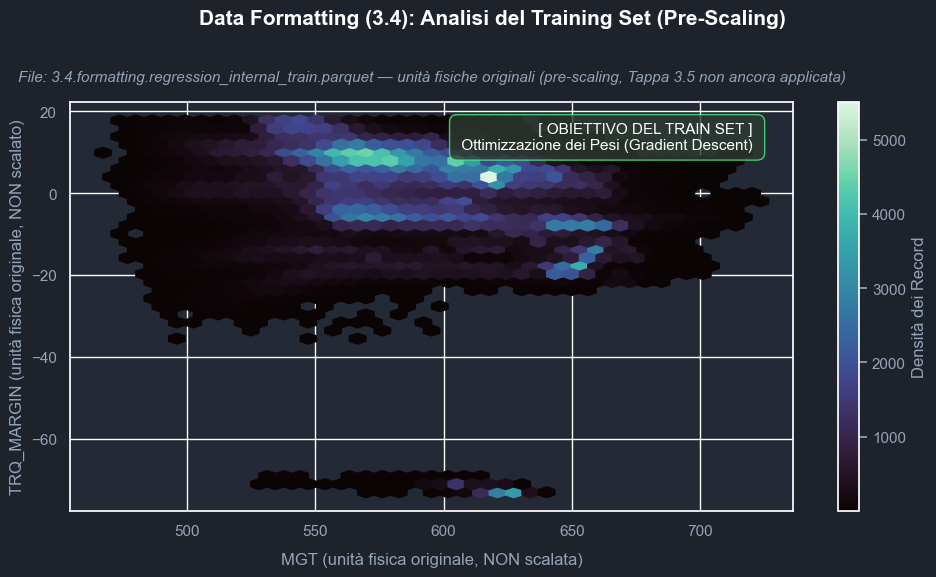


 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL TRAIN SET (TAPPA 3.4, PRE-SCALING)
Questo file costituisce la 'Ground Truth' (~70% dei dati) su cui il modello
calcolerà il gradiente dell'errore (Loss Function). Il grafico Hexbin evidenzia
le relazioni non lineari (Pattern) tra i predittori (es. MGT) e il Target.

NOTA IMPORTANTE (correzione): questo file proviene dalla Tappa 3.4 (Data
Split), eseguita PRIMA della Tappa 3.5 (Scaling). I valori mostrati sono
quindi nelle unità fisiche originali dei sensori — NON centrati sullo zero
né normalizzati. Lo spazio vettoriale scalato attorno allo zero (RobustScaler)
viene generato solo nella Tappa 3.5 successiva, verificato separatamente più
avanti in questo notebook.



In [19]:

# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================


filename_train_final = "3.4.formatting.regression_internal_train.parquet"
file_path_train_final = base_phase_path / filename_train_final

# Lettura del Training Set Definitivo
df_train_final = pd.read_parquet(file_path_train_final)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Selezioniamo una feature rappresentativa (MGT - Measured Gas Temperature)
# contro il target (TRQ_MARGIN) per visualizzare il manifold dei dati.
x_col = 'mgt'
y_col = 'trq_margin'

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Train Space Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Usiamo un Hexbin plot per gestire la densità visiva dei punti scalati
hb = ax.hexbin(df_train_final[x_col], df_train_final[y_col], gridsize=40, cmap='mako', mincnt=1)

# Titoli e annotazioni
fig.suptitle("Data Formatting (3.4): Analisi del Training Set (Pre-Scaling)", fontsize=15, fontweight='bold', color='white', y=0.96)
ax.set_title(f"File: {filename_train_final} — unità fisiche originali (pre-scaling, Tappa 3.5 non ancora applicata)", fontsize=11, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel(f"{x_col.upper()} (unità fisica originale, NON scalata)", color='#94a3b8', labelpad=10)
ax.set_ylabel(f"{y_col.upper()} (unità fisica originale, NON scalato)", color='#94a3b8')
ax.tick_params(colors='#94a3b8')

# Colorbar per la densità
cb = fig.colorbar(hb, ax=ax)
cb.set_label('Densità dei Record', color='#94a3b8')
cb.ax.yaxis.set_tick_params(color='#94a3b8', labelcolor='#94a3b8')

# Box Informativo
props = dict(boxstyle="round,pad=0.5", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax.text(0.95, 0.95, " [ OBIETTIVO DEL TRAIN SET ] \n Ottimizzazione dei Pesi (Gradient Descent) ",
        transform=ax.transAxes, fontsize=11, color="white", va="top", ha="right", bbox=props)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_train = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL TRAIN SET (TAPPA 3.4, PRE-SCALING)
================================================================================
Questo file costituisce la 'Ground Truth' (~70% dei dati) su cui il modello
calcolerà il gradiente dell'errore (Loss Function). Il grafico Hexbin evidenzia
le relazioni non lineari (Pattern) tra i predittori (es. MGT) e il Target.

NOTA IMPORTANTE (correzione): questo file proviene dalla Tappa 3.4 (Data
Split), eseguita PRIMA della Tappa 3.5 (Scaling). I valori mostrati sono
quindi nelle unità fisiche originali dei sensori — NON centrati sullo zero
né normalizzati. Lo spazio vettoriale scalato attorno allo zero (RobustScaler)
viene generato solo nella Tappa 3.5 successiva, verificato separatamente più
avanti in questo notebook.
================================================================================
"""
print(analisi_train)

In [20]:
path_x_y_train_3_4_internal = base_run_dir / "phase3_data_preparation" / (
    "3.4.formatting.regression_internal_train.parquet")

query_schema_train = (f"DESCRIBE SELECT * FROM parquet_scan"
                      f"('{path_x_y_train_3_4_internal}')")

print("--- STRUTTURA DATASET DI x_y_train_3_4_internal (pre-scaling) ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")
query = f"SELECT * FROM '{path_x_y_train_3_4_internal}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)

--- STRUTTURA DATASET DI x_y_train_3_4_internal (pre-scaling) ---
             column_name column_type
0                    oat      DOUBLE
1                    mgt      DOUBLE
2                     pa      DOUBLE
3                    ias      DOUBLE
4                     np      DOUBLE
5                     ng      DOUBLE
6           trq_measured      DOUBLE
7                 faulty      BIGINT
8             trq_margin      DOUBLE
9          mgt_oat_ratio      DOUBLE
10  specific_power_index      DOUBLE
11                 oat^2      DOUBLE
12               oat mgt      DOUBLE
13                oat pa      DOUBLE
14               oat ias      DOUBLE
15                oat np      DOUBLE
16                oat ng      DOUBLE
17      oat trq_measured      DOUBLE
18                 mgt^2      DOUBLE
19                mgt pa      DOUBLE
20               mgt ias      DOUBLE
21                mgt np      DOUBLE
22                mgt ng      DOUBLE
23      mgt trq_measured      DOUBLE
24       

,oat,mgt,pa,ias,np,ng,trq_measured,faulty,trq_margin,mgt_oat_ratio,...,ias^2,ias np,ias ng,ias trq_measured,np^2,np ng,np trq_measured,ng^2,ng trq_measured,trq_measured^2
0,4.453769,559.2656,5.821031,114.7656,100.3906,92.03699,68.36914,1,4.221104,2.014618,...,13171.142943,11521.387443,10562.680380,7846.425374,10078.272568,9239.648648,6863.618986,8470.807528,6292.489854,4674.339304
1,14.000000,562.1000,1315.212000,55.8125,99.9800,90.77000,51.00000,1,-5.352514,1.957513,...,3115.035156,5580.133750,5066.100625,2846.437500,9996.000400,9075.184600,5098.980000,8239.192900,4629.270000,2601.000000
2,3.500000,559.6000,231.648000,15.8125,99.8200,91.28000,70.00000,0,6.009979,2.022772,...,250.035156,1578.403750,1443.365000,1106.875000,9964.032400,9111.569600,6987.400000,8332.038400,6389.600000,4900.000000
3,12.750000,632.3000,422.452800,88.3750,99.6200,95.19000,72.50000,1,-8.783940,2.211612,...,7810.140625,8803.917500,8412.416250,6407.187500,9924.144400,9482.827800,7222.450000,9061.136100,6901.275000,5256.250000
4,11.500000,647.6000,437.388000,116.3750,96.4100,99.79000,78.60000,0,-7.795901,2.275075,...,13543.140625,11219.713750,11613.061250,9147.075000,9294.888100,9620.753900,7577.826000,9958.044100,7843.494000,6177.960000


In [21]:
# =============================================================================
# LIBRERIE
# =============================================================================
import pandas as pd
from IPython.display import display, Markdown

# NOTA: Si presuppone che 'base_run_dir' sia già definita dinamicamente nel notebook
# base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# =============================================================================
# 1. FASE DI INPUT: Definizione percorsi e caricamento del Parquet della Tappa 3
# =============================================================================

# 1.1 Configurazione dinamica del percorso della Tappa 3 per evitare hardcoding del drive
base_phase3_path = base_run_dir / "phase3_data_preparation"
filename_train_final = "3.4.formatting.regression_internal_train.parquet"
file_path_train_final = base_phase3_path / filename_train_final

# 1.2 Caricamento del dataset di addestramento in memoria
try:
    df_train = pd.read_parquet(file_path_train_final)
    print(f"Dataset di addestramento caricato con successo da: {filename_train_final}")
    print(f"Dimensioni del subset: {df_train.shape[0]} righe, {df_train.shape[1]} colonne totali.")
except FileNotFoundError:
    print(f"⚠️ ERRORE CRITICO: Impossibile trovare il file Parquet nel percorso: {file_path_train_final}")

# =============================================================================
# 2. FASE DI LOGICA: Isolamento delle feature ed estrazione dei metadati
# =============================================================================

# 2.1 Esclusione della variabile target ('trq_margin') per isolare solo i predittori del modello
target_column = 'trq_margin'
columnas_modelo = [col for col in df_train.columns if col != target_column]
num_features = len(columnas_modelo)

# 2.2 Controllo di consistenza: verifica dimensionale con il modello NGBoost
# NOTA: questo controllo è utile SOLO se questo notebook viene eseguito nella
# stessa sessione/kernel di un notebook di training (Fase 4) che ha già
# lasciato 'model' in memoria. In esecuzione NORMALE e isolata di questo
# notebook (Fase 3, preprocessamento) 'model' non esiste mai: il controllo
# stamperà correttamente "nessun modello disponibile" — non è un errore,
# è un placeholder informativo per un eventuale uso combinato dei notebook.
current_model = globals().get('model', None)

if current_model is not None:
    try:
        import numpy as np
        feat_imp = current_model.feature_importances_

        # Gestione difensiva del formato delle feature importances di NGBoost
        if isinstance(feat_imp, list):
            # Se NGBoost restituisce una lista di array (uno per ogni parametro della distribuzione, es. loc e scale)
            expected_by_model = len(feat_imp[0])
        elif isinstance(feat_imp, np.ndarray):
            # Se restituisce un array NumPy (unificato o monodimensionale)
            expected_by_model = feat_imp.shape[0] if feat_imp.ndim == 1 else feat_imp.shape[1]
        else:
            # Fallback standard per altri formati
            expected_by_model = len(feat_imp)

        if num_features == expected_by_model:
            print(f"✅ Allineamento perfetto: Il dataset ha {num_features} feature e il modello attende {expected_by_model}.")
        else:
            print(f"⚠️ DISALLINEAMENTO DETECTED: Dataset = {num_features} | Modello attende = {expected_by_model}.")

    except Exception as e:
        print(f"ℹ️ Nota sull'auditing del modello: Impossibile estrarre le feature importances ({str(e)}).")
        print("   Assicurarsi che il modello sia stato correttamente addestrato (.fit()) prima di questo controllo.")
else:
    print("ℹ️ Nessun modello disponibile in memoria ('model' non trovato in globals()). Controllo di consistenza saltato.")

# =============================================================================
# 3. FASE DI DISEGNO / OUTPUT: Stampa ordinata delle variabili reali
# =============================================================================
print(f"\nNomi reali delle {num_features} variabili in ordine sequenziale:\n")
print("-" * 60)
for i, nombre in enumerate(columnas_modelo):
    print(f"Feature_{i:02d}: {nombre}")
print("-" * 60)

# =============================================================================
# 4. FASE DI ANALISI FINALE
# =============================================================================

analisi_testo = f"""
### 4. Fase di Analisi Finale (Verifica di Integrità tra Tappa 3 – Estrazione Feature e Tappa 4 – Addestramento)

Nell'ambito del passaggio tra la Tappa 3 (Estrazione Feature) e la Tappa 4 (Addestramento) del workflow di diagnosi data-driven, l'ispezione programmatica dei metadati del file `{filename_train_final}` ha permesso di mappare con precisione lo spazio dimensionale degli input reali del sistema. L'esclusione della variabile target (`{target_column}`) consente di isolare rigorosamente l'elenco sequenziale delle {num_features} variabili predittive destinate all'algoritmo.

"""

# Rendering automatico dell'analisi nel notebook sotto l'output del codice
display(Markdown(analisi_testo))

Dataset di addestramento caricato con successo da: 3.4.formatting.regression_internal_train.parquet
Dimensioni del subset: 478117 righe, 39 colonne totali.
ℹ️ Nessun modello disponibile in memoria ('model' non trovato in globals()). Controllo di consistenza saltato.

Nomi reali delle 38 variabili in ordine sequenziale:

------------------------------------------------------------
Feature_00: oat
Feature_01: mgt
Feature_02: pa
Feature_03: ias
Feature_04: np
Feature_05: ng
Feature_06: trq_measured
Feature_07: faulty
Feature_08: mgt_oat_ratio
Feature_09: specific_power_index
Feature_10: oat^2
Feature_11: oat mgt
Feature_12: oat pa
Feature_13: oat ias
Feature_14: oat np
Feature_15: oat ng
Feature_16: oat trq_measured
Feature_17: mgt^2
Feature_18: mgt pa
Feature_19: mgt ias
Feature_20: mgt np
Feature_21: mgt ng
Feature_22: mgt trq_measured
Feature_23: pa^2
Feature_24: pa ias
Feature_25: pa np
Feature_26: pa ng
Feature_27: pa trq_measured
Feature_28: ias^2
Feature_29: ias np
Feature_30: ias 


### 4. Fase di Analisi Finale (Verifica di Integrità tra Tappa 3 – Estrazione Feature e Tappa 4 – Addestramento)

Nell'ambito del passaggio tra la Tappa 3 (Estrazione Feature) e la Tappa 4 (Addestramento) del workflow di diagnosi data-driven, l'ispezione programmatica dei metadati del file `3.4.formatting.regression_internal_train.parquet` ha permesso di mappare con precisione lo spazio dimensionale degli input reali del sistema. L'esclusione della variabile target (`trq_margin`) consente di isolare rigorosamente l'elenco sequenziale delle 38 variabili predittive destinate all'algoritmo.



**Termini nel grafico:**
- **Violin plot**: combina un boxplot con la densità di distribuzione (KDE) su ciascun lato — permette di vedere sia i quartili sia la forma della distribuzione.
- **Covariate shift**: differenza nella distribuzione delle feature tra due partizioni (qui: train vs. validation); la sua assenza è un buon segnale per l'affidabilità del tuning degli iperparametri.

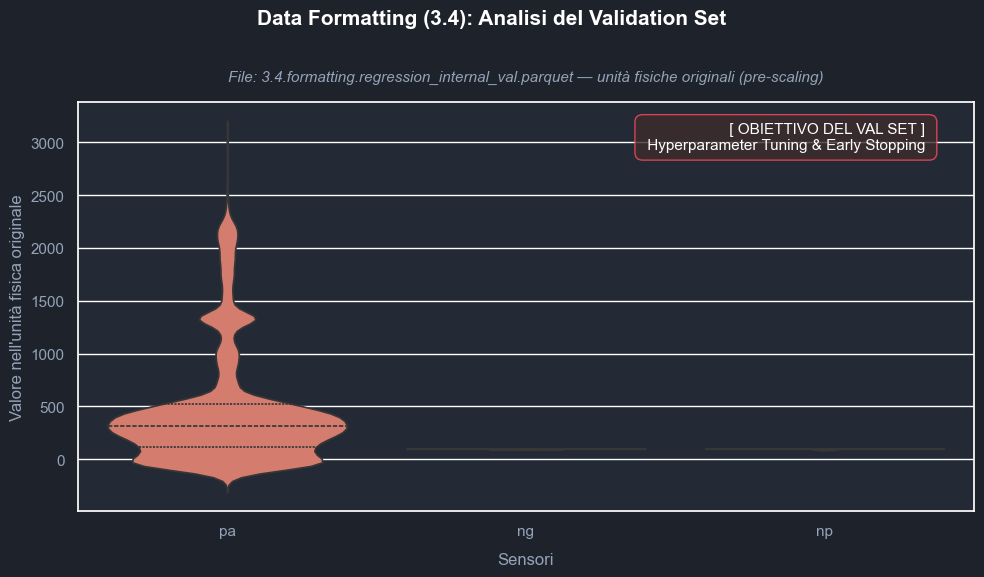


 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL VALIDATION SET
Il Validation Set (~15% dei dati) è l'ambiente di 'collaudo intermedio'.
Questo file (3.4.formatting.regression_internal_val.parquet) rappresenta
lo split PRIMA dell'applicazione del RobustScaler (Tappa 3.5): i valori
sono quindi nelle unità fisiche originali dei sensori, non normalizzati.
I grafici a violino confermano che le features mantengono distribuzioni
coerenti anche in questo sottoinsieme, senza evidenza di 'Covariate Shift'
(slittamento delle distribuzioni rispetto al Train nella stessa unità).




In [22]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

filename_val_final = "3.4.formatting.regression_internal_val.parquet"
file_path_val_final = base_phase_path / filename_val_final

df_val_final = pd.read_parquet(file_path_val_final)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estraiamo alcune features rappresentative per verificare l'assenza
# di "Covariate Shift" (le distribuzioni devono rimanere stabili).
#
# NOTA IMPORTANTE: questo file proviene dalla Tappa 3.4 (Data Split),
# eseguita PRIMA della Tappa 3.5 (Scaling). I valori qui sono quindi
# nelle unità fisiche originali dei sensori, NON normalizzati.
# Il grafico va interpretato di conseguenza (vedi titolo/etichette sotto).
features_da_ispezionare = ['pa', 'ng', 'np']
df_val_melted = df_val_final[features_da_ispezionare].melt(var_name='Feature', value_name='Valore')

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Validation Stability Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#1e222b')
ax.set_facecolor('#242936')

# Violin Plot corretto: aggiunto hue='Feature' e legend=False per evitare il FutureWarning
sns.violinplot(
    x='Feature',
    y='Valore',
    data=df_val_melted,
    ax=ax,
    hue='Feature',
    palette='flare',
    inner='quartile',
    legend=False
)

fig.suptitle("Data Formatting (3.4): Analisi del Validation Set", fontsize=15, fontweight='bold', color='white', y=0.96)
ax.set_title(f"File: {filename_val_final} — unità fisiche originali (pre-scaling)", fontsize=11, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel("Sensori", color='#94a3b8', labelpad=10)
ax.set_ylabel("Valore nell'unità fisica originale", color='#94a3b8')
ax.tick_params(colors='#94a3b8')
# NOTA: rimosso ax.set_ylim(-4, 4) hardcoded — presupponeva dati già
# scalati (tipico range RobustScaler). Su dati non scalati causava una
# distorsione visiva: 'pa' appariva come blocco pieno e 'ng'/'np'
# risultavano invisibili, perché i loro range reali (es. pa~900-1200,
# ng/np~80-105) cadevano interamente fuori dalla finestra fissa.
# Si lascia che matplotlib scali automaticamente in base ai dati reali.

# Box Informativo
props = dict(boxstyle="round,pad=0.5", facecolor="#3d2c2d", alpha=0.8, edgecolor="#ff4b5c")
ax.text(0.95, 0.95, " [ OBIETTIVO DEL VAL SET ] \n Hyperparameter Tuning & Early Stopping ",
        transform=ax.transAxes, fontsize=11, color="white", va="top", ha="right", bbox=props)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_val = """
================================================================================
 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL VALIDATION SET
================================================================================
Il Validation Set (~15% dei dati) è l'ambiente di 'collaudo intermedio'.
Questo file (3.4.formatting.regression_internal_val.parquet) rappresenta
lo split PRIMA dell'applicazione del RobustScaler (Tappa 3.5): i valori
sono quindi nelle unità fisiche originali dei sensori, non normalizzati.
I grafici a violino confermano che le features mantengono distribuzioni
coerenti anche in questo sottoinsieme, senza evidenza di 'Covariate Shift'
(slittamento delle distribuzioni rispetto al Train nella stessa unità).

================================================================================
"""
print(analisi_val)

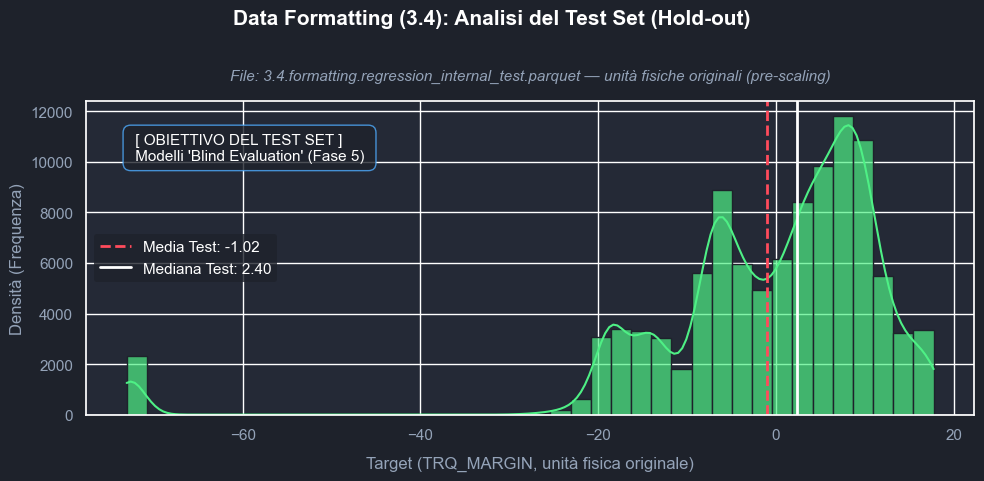


 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL TEST SET
Il Test Set (il restante 15%) è il set di Hold-out (cieco). Il file analizzato
(3.4.formatting.regression_internal_test.parquet) contiene trq_margin nella
sua unità fisica originale, PRIMA dell'applicazione del RobustScaler (Tappa 3.5).

Media Test: -1.02 | Mediana Test: 2.40
Il divario tra Media e Mediana (3.42) NON indica una distribuzione
simmetrica: è coerente con l'asimmetria severa già documentata in Tappa 2.2
(skewness = -2.752), confermata anche visivamente dalla coda estesa verso
i valori negativi e dalla forma bimodale dell'istogramma. Questo split
riflette correttamente la stessa asimmetria del dataset di origine — non
è un difetto della partizione, ma va tenuto presente in Fase 5: metriche
come RMSE possono essere sensibili a questa asimmetria, e vale la pena
affiancarle con metriche robuste (es. MAE, mediana degli errori) per non
sovrastimare l'accuratezza attesa in un ambiente industriale reale.



In [23]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
filename_test_final = "3.4.formatting.regression_internal_test.parquet"
file_path_test_final = base_phase_path / filename_test_final

df_test_final = pd.read_parquet(file_path_test_final)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# NOTA: questo file proviene dalla Tappa 3.4 (Data Split), eseguita PRIMA
# della Tappa 3.5 (Scaling). I valori di trq_margin qui sono quindi nella
# loro unità fisica originale (già clippata al 1°/99° percentile in 3.2,
# bounds: -73.043 / 17.721), NON scalati con RobustScaler.
target_col = 'trq_margin'
target_test = df_test_final[target_col]

media_test = target_test.mean()
mediana_test = target_test.median()
skew_gap = mediana_test - media_test

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Test Integrity Dashboard)
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e222b')
ax.set_facecolor('#242936')

sns.histplot(target_test, bins=40, kde=True, color='#4ef085', ax=ax, edgecolor='#1e222b', alpha=0.7)

fig.suptitle("Data Formatting (3.4): Analisi del Test Set (Hold-out)", fontsize=15, fontweight='bold', color='white', y=0.96)
ax.set_title(f"File: {filename_test_final} — unità fisiche originali (pre-scaling)", fontsize=11, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel("Target (TRQ_MARGIN, unità fisica originale)", color='#94a3b8', labelpad=10)
ax.set_ylabel("Densità (Frequenza)", color='#94a3b8')
ax.tick_params(colors='#94a3b8')

ax.axvline(media_test, color='#ff4b5c', linestyle='--', linewidth=2, label=f"Media Test: {media_test:.2f}")
ax.axvline(mediana_test, color='white', linestyle='-', linewidth=2, label=f"Mediana Test: {mediana_test:.2f}")

# Box Informativo
props = dict(boxstyle="round,pad=0.5", facecolor="#1e222b", alpha=0.8, edgecolor="#4facfe")
ax.text(0.05, 0.85, " [ OBIETTIVO DEL TEST SET ] \n Modelli 'Blind Evaluation' (Fase 5) ",
        transform=ax.transAxes, fontsize=11, color="white", va="center", ha="left", bbox=props)

ax.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_test = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: REGRESSION INTERNAL TEST SET
================================================================================
Il Test Set (il restante 15%) è il set di Hold-out (cieco). Il file analizzato
(3.4.formatting.regression_internal_test.parquet) contiene trq_margin nella
sua unità fisica originale, PRIMA dell'applicazione del RobustScaler (Tappa 3.5).

Media Test: {media_test:.2f} | Mediana Test: {mediana_test:.2f}
Il divario tra Media e Mediana ({skew_gap:.2f}) NON indica una distribuzione
simmetrica: è coerente con l'asimmetria severa già documentata in Tappa 2.2
(skewness = -2.752), confermata anche visivamente dalla coda estesa verso
i valori negativi e dalla forma bimodale dell'istogramma. Questo split
riflette correttamente la stessa asimmetria del dataset di origine — non
è un difetto della partizione, ma va tenuto presente in Fase 5: metriche
come RMSE possono essere sensibili a questa asimmetria, e vale la pena
affiancarle con metriche robuste (es. MAE, mediana degli errori) per non
sovrastimare l'accuratezza attesa in un ambiente industriale reale.
================================================================================
"""
print(analisi_test)

In [24]:
# =============================================================================
# AUDITING FINALE (TAPPA 3.4): TRAIN, TEST, VALIDATION DATASETS
# =============================================================================
# Definizione dei percorsi per i tre dataset formattati per la regressione
path_x_y_train_3_4 = base_run_dir / "phase3_data_preparation" / ("3.4.formatting.regression_internal_train.parquet")
path_x_y_test_3_4  = base_run_dir / "phase3_data_preparation" / ("3.4.formatting.regression_internal_test.parquet")
path_x_y_val_3_4   = base_run_dir / "phase3_data_preparation" / ("3.4.formatting.regression_internal_val.parquet")


datasets_formatting = {
    "TRAIN (Internal)": path_x_y_train_3_4,
    "TEST (Internal)":  path_x_y_test_3_4,
    "VAL (Internal)":   path_x_y_val_3_4
}

# --- 1. CONTEGGIO COMPLESSIVO DEI RECORD (UNION) ---
print(f"{'='*60}")
print("📊 CONTEGGIO RECORD TOTALI (TRAIN, TEST, VAL)")
print(f"{'='*60}")

query_conteos = f"""
WITH totali AS (
    SELECT 'TRAIN (Internal)' as dataset, count(*) as record_totali FROM parquet_scan('{path_x_y_train_3_4}')
    UNION ALL
    SELECT 'TEST (Internal)' as dataset, count(*) as record_totali FROM parquet_scan('{path_x_y_test_3_4}')
    UNION ALL
    SELECT 'VAL (Internal)' as dataset, count(*) as record_totali FROM parquet_scan('{path_x_y_val_3_4}')
)
SELECT
    dataset,
    record_totali,
    ROUND((record_totali * 100.0) / SUM(record_totali) OVER(), 2) || '%' as percentuale
FROM totali
"""
df_conteggi = duckdb.query(query_conteos).to_df()
display(df_conteggi)

print("\n" + "-"*60 + "\n")

# --- 2. VERIFICA DEGLI SCHEMI E TIPOLOGIA DELLE COLONNE (ALL DATASETS) ---
print(f"{'='*60}")
print("📋 CONFRONTO SCHEMI E STRUTTURA DELLE COLONNE")
print(f"{'='*60}")

# Iteriamo su ogni dataset per estrarre lo schema specifico
for nome_ds, path_ds in datasets_formatting.items():
    print(f"\n🔹 Struttura Colonne per: {nome_ds}")
    query_schema = f"DESCRIBE SELECT * FROM parquet_scan('{path_ds}')"
    df_schema = duckdb.query(query_schema).to_df()[['column_name', 'column_type']]
    display(df_schema)

print("\n" + "-"*60 + "\n")

# --- 3. ANTEPRIMA DEI DATI (SAMPLED PREVIEW - LIMIT 3 PER OGNI DATASET) ---
print(f"{'='*60}")
print("🔍 ANTEPRIMA DEI DATI (FIRST 3 ROWS FOR EACH DATASET)")
print(f"{'='*60}")

for nome_ds, path_ds in datasets_formatting.items():
    print(f"\n🔹 Primi 3 record di: {nome_ds}")
    query_preview = f"SELECT * FROM parquet_scan('{path_ds}') LIMIT 3"
    df_preview = duckdb.query(query_preview).to_df()
    display(df_preview)

📊 CONTEGGIO RECORD TOTALI (TRAIN, TEST, VAL)


,dataset,record_totali,percentuale
0,TRAIN (Internal),478117,70.0%
1,TEST (Internal),102454,15.0%
2,VAL (Internal),102454,15.0%



------------------------------------------------------------

📋 CONFRONTO SCHEMI E STRUTTURA DELLE COLONNE

🔹 Struttura Colonne per: TRAIN (Internal)


,column_name,column_type
0,oat,DOUBLE
1,mgt,DOUBLE
2,pa,DOUBLE
3,ias,DOUBLE
4,np,DOUBLE
5,ng,DOUBLE
6,trq_measured,DOUBLE
7,faulty,BIGINT
8,trq_margin,DOUBLE
9,mgt_oat_ratio,DOUBLE



🔹 Struttura Colonne per: TEST (Internal)


...

,oat,mgt,pa,ias,np,ng,trq_measured,faulty,trq_margin,mgt_oat_ratio,...,ias^2,ias np,ias ng,ias trq_measured,np^2,np ng,np trq_measured,ng^2,ng trq_measured,trq_measured^2
0,4.453769,559.2656,5.821031,114.7656,100.3906,92.03699,68.36914,1,4.221104,2.014618,...,13171.142943,11521.387443,10562.680380,7846.425374,10078.272568,9239.648648,6863.618986,8470.807528,6292.489854,4674.339304
1,14.000000,562.1000,1315.212000,55.8125,99.9800,90.77000,51.00000,1,-5.352514,1.957513,...,3115.035156,5580.133750,5066.100625,2846.437500,9996.000400,9075.184600,5098.980000,8239.192900,4629.270000,2601.000000
2,3.500000,559.6000,231.648000,15.8125,99.8200,91.28000,70.00000,0,6.009979,2.022772,...,250.035156,1578.403750,1443.365000,1106.875000,9964.032400,9111.569600,6987.400000,8332.038400,6389.600000,4900.000000



🔹 Primi 3 record di: TEST (Internal)


,oat,mgt,pa,ias,np,ng,trq_measured,faulty,trq_margin,mgt_oat_ratio,...,ias^2,ias np,ias ng,ias trq_measured,np^2,np ng,np trq_measured,ng^2,ng trq_measured,trq_measured^2
0,19.75,532.2,-80.4672,63.625,87.88,99.85,42.2,0,0.898302,1.817002,...,4048.140625,5591.3650,6352.95625,2684.975,7722.8944,8774.8180,3708.536,9970.0225,4213.670,1780.84
1,21.00,570.9,136.8552,69.000,100.34,90.93,57.9,0,9.041022,1.940847,...,4761.000000,6923.4600,6274.17000,3995.100,10068.1156,9123.9162,5809.686,8268.2649,5264.847,3352.41
2,1.00,655.4,575.4624,123.250,96.33,99.97,84.6,1,-12.716541,2.390662,...,15190.562500,11872.6725,12321.30250,10426.950,9279.4689,9630.1101,8149.518,9994.0009,8457.462,7157.16



🔹 Primi 3 record di: VAL (Internal)


,oat,mgt,pa,ias,np,ng,trq_measured,faulty,trq_margin,mgt_oat_ratio,...,ias^2,ias np,ias ng,ias trq_measured,np^2,np ng,np trq_measured,ng^2,ng trq_measured,trq_measured^2
0,-9.75,650.7,796.4424,119.4375,95.86,100.13,86.0,1,-18.184318,2.470387,...,14265.316406,11449.278750,11959.276875,10271.62500,9189.1396,9598.4618,8243.960,10026.0169,8611.180,7396.00
1,6.75,555.4,395.0208,102.6250,99.68,92.17,68.9,0,12.808220,1.984280,...,10531.890625,10229.660000,9458.946250,7070.86250,9936.1024,9187.5056,6867.952,8495.3089,6350.513,4747.21
2,12.25,602.3,255.1176,51.6875,100.13,93.31,67.5,1,-5.047433,2.110371,...,2671.597656,5175.469375,4822.960625,3488.90625,10026.0169,9343.1303,6758.775,8706.7561,6298.425,4556.25


## 3. Estrazione Feature (cont.) — Data Transformation (Scaling)

Normalizzazione delle feature tramite `RobustScaler`, calcolato esclusivamente sul training set per evitare data leakage verso validation/test.

In [25]:
# ----------------------------------------------------------------
# ---------------- DATA TRANSFORMATION step_3_5_data_transformation
# ----------------------------------------------------------------

**Termini nel grafico:**
- **RobustScaler**: a differenza dello StandardScaler (che usa media e deviazione standard), centra i dati sulla **mediana** e li scala per l'**IQR** (ampiezza interquartile) — più resistente all'influenza degli outlier.

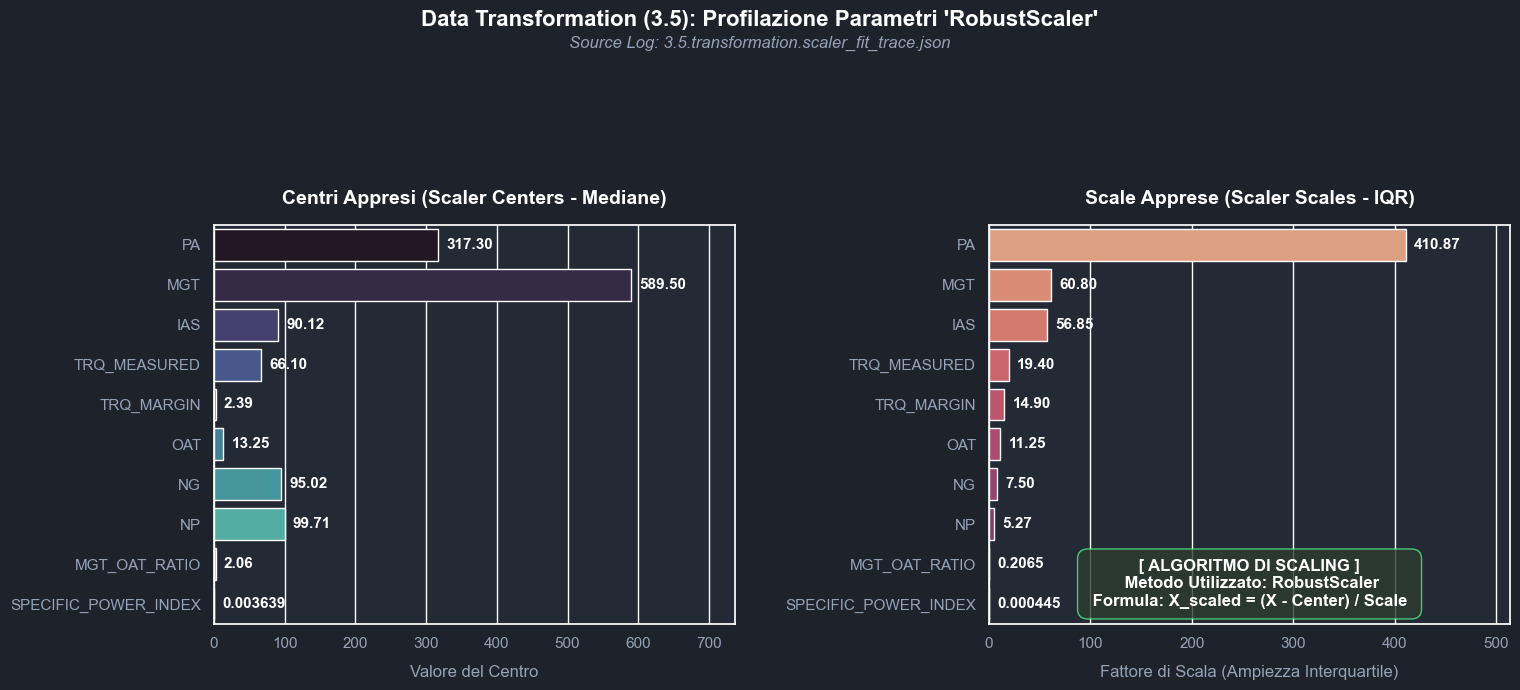


 📊 ANALISI CONCLUSIVA: TRASFORMAZIONE E NORMALIZZAZIONE DATI (TAPPA 3.5)
L'analisi del file di tracciamento (3.5.transformation.scaler_fit_trace.json) certifica l'avvenuto
calcolo dei parametri di normalizzazione (Data Scaling) sul set di addestramento.

1. SCELTA DELL'ALGORITMO (ROBUST SCALER) — evidenza dalle Tappe 2.2 (⚠️ struttura di 2.2.data_description-distribution_analysis.json non riconosciuta — chiavi di primo livello: ['classification', 'regression', 'fit_results'])
   e 3.2 (letto da 3.2.cleaning.clipping_audit_log.json):
   La pipeline ha utilizzato l'algoritmo 'RobustScaler'. Questa scelta è
   direttamente giustificata da due evidenze numeriche già raccolte nelle
   tappe precedenti, non da una preferenza generica:
   - Tappa 2.2 (Descrizione dati): la distribuzione di 'trq_margin' presenta
     una skewness di -2.752 (asimmetria severa). Nessun fit
     teorico standard è risultato valido: SkewNormal (KS p-value=0.0)
     e Gamma (KS p-value=0.0) sono stati entrambi res

In [26]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================

# Definizione dinamica del file di log per lo scaler
filename_scaler = "3.5.transformation.scaler_fit_trace.json"
file_path_scaler = base_phase_path / filename_scaler

# Lettura dinamica del file JSON (L'INPUT ENTRA QUI)
with open(file_path_scaler, "r", encoding="utf-8") as f:
    scaler_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# Estrazione dei metadati del fitting dello scaler

metodo_scaling = scaler_data["method"]
features = scaler_data["features_scaled"]
centri = scaler_data["scaler_centers_"]
scale = scaler_data["scaler_scales_"]

# Logica: Creazione di un DataFrame per facilitare il plotting con Seaborn
df_scaler = pd.DataFrame({
    'Feature': [f.upper() for f in features],
    'Center (Mediana)': centri,
    'Scale (IQR)': scale
})

# Ordinamento in base alla scala (dal più grande al più piccolo) per una migliore estetica
df_scaler = df_scaler.sort_values(by='Scale (IQR)', ascending=False).reset_index(drop=True)


def format_valore(v: float) -> str:
    """Formattazione adattiva: evita che valori piccoli (es. specific_power_index,
    dell'ordine di 1e-3/1e-4) vengano troncati a '0.00' e sembrino nulli/non calcolati."""
    if v == 0:
        return "0.00"
    if abs(v) < 0.01:
        return f"{v:.6f}"
    if abs(v) < 1:
        return f"{v:.4f}"
    return f"{v:.2f}"


# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Scaler Fit Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione della figura con 2 subplot (1 riga, 2 colonne)
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO (Source Log)
fig.suptitle(f"Data Transformation (3.5): Profilazione Parametri '{metodo_scaling}'",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.91, f"Source Log: {filename_scaler}",
         fontsize=12, style='italic', color='#94a3b8', ha='center')

# --- GRAFICO A: Centri (Mediane) ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

sns.barplot(x='Center (Mediana)', y='Feature', data=df_scaler, ax=ax1, palette="mako", hue='Feature', legend=False)
ax1.set_title("Centri Appresi (Scaler Centers - Mediane)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Valore del Centro", color='#94a3b8', labelpad=10)
ax1.set_ylabel("", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Etichette numeriche sui centri (formato adattivo)
for i, row in df_scaler.iterrows():
    ax1.text(row['Center (Mediana)'] + (df_scaler['Center (Mediana)'].max() * 0.02), i,
             format_valore(row['Center (Mediana)']), va='center', ha='left', fontweight='bold', color='white', fontsize=11)

# --- GRAFICO B: Scale (Interquartile Range) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

sns.barplot(x='Scale (IQR)', y='Feature', data=df_scaler, ax=ax2, palette="flare", hue='Feature', legend=False)
ax2.set_title("Scale Apprese (Scaler Scales - IQR)", fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Fattore di Scala (Ampiezza Interquartile)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Etichette numeriche sulle scale (formato adattivo)
for i, row in df_scaler.iterrows():
    ax2.text(row['Scale (IQR)'] + (df_scaler['Scale (IQR)'].max() * 0.02), i,
             format_valore(row['Scale (IQR)']), va='center', ha='left', fontweight='bold', color='white', fontsize=11)

# Aggiunta di un Box Informativo per spiegare il metodo (Senza emoji per Matplotlib)
testo_metodo = (
    f" [ ALGORITMO DI SCALING ] \n"
    f" Metodo Utilizzato: {metodo_scaling}\n"
    f" Formula: X_scaled = (X - Center) / Scale "
)
props_metodo = dict(boxstyle="round,pad=0.6", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax2.text(0.50, 0.10, testo_metodo, transform=ax2.transAxes, fontsize=12, color="white",
         va="center", ha="center", bbox=props_metodo, fontweight='bold')

# Regolazione asse X per non tagliare le etichette
ax1.set_xlim(0, df_scaler['Center (Mediana)'].max() * 1.25)
ax2.set_xlim(0, df_scaler['Scale (IQR)'].max() * 1.25)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88]) # Ajustiamo il layout per fare spazio al titolo
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

# --- LETTURA DINAMICA (non hardcoded) dei valori incrociati da altre Tappe ---
# Stesso principio applicato nel resto dell'audit: nessun numero copiato a
# mano, tutto letto dai file reali al momento dell'esecuzione.

# 1. Numero totale di colonne: letto dallo schema REALE del parquet di 3.3
#    (non un conteggio fisso assunto una volta e mai riverificato).
filename_transformed_33 = "3.3.transformation.transformed_regression_train.parquet"
file_path_transformed_33 = base_phase_path / filename_transformed_33
try:
    schema_33 = duckdb.query(
        f"DESCRIBE SELECT * FROM parquet_scan('{file_path_transformed_33}')"
    ).to_df()
    n_totale_colonne = len(schema_33)
    fonte_n_colonne = f"schema reale di {filename_transformed_33}"
except Exception as e:
    n_totale_colonne = 39
    fonte_n_colonne = f"⚠️ FALLBACK non verificato in questa esecuzione ({e})"
n_non_scalate = n_totale_colonne - len(features)

# 2. Skewness e test KS del target originale: letti da 2.2 (Fase di
#    Acquisizione dati). Estrazione DIFENSIVA: prova più pattern comuni di
#    struttura JSON; se nessuno funziona, espone le chiavi reali invece di
#    fallire in silenzio (stesso approccio già applicato al fix del
#    KS-test nel notebook di Fase 4).
filename_dist_22 = "2.2.data_description-distribution_analysis.json"
file_path_dist_22 = base_run_dir / "phase2_data_understanding" / filename_dist_22

skewness_target, skewnorm_ks_p, gamma_ks_p = None, None, None
fonte_skew = f"⚠️ {filename_dist_22} non disponibile in questa esecuzione"
try:
    with open(file_path_dist_22, "r", encoding="utf-8") as f:
        dist_data = json.load(f)
    target_block = dist_data.get(target_col, dist_data.get("trq_margin", dist_data))
    skewness_target = target_block.get("skewness") if isinstance(target_block, dict) else None
    fits = target_block.get("fits", target_block) if isinstance(target_block, dict) else {}
    skewnorm_ks_p = (fits.get("skewnorm", {}) or fits.get("SkewNormal", {})).get("ks_pvalue")         if isinstance(fits, dict) else None
    gamma_ks_p = (fits.get("gamma", {}) or fits.get("Gamma", {})).get("ks_pvalue")         if isinstance(fits, dict) else None
    if skewness_target is not None:
        fonte_skew = f"letto da {filename_dist_22}"
    else:
        fonte_skew = (f"⚠️ struttura di {filename_dist_22} non riconosciuta — "
                      f"chiavi di primo livello: {list(dist_data.keys())}")
except FileNotFoundError:
    pass
if skewness_target is None:
    # Fallback dichiarato esplicitamente come NON verificato in questa run,
    # invece di presentarlo come se fosse stato letto ora
    skewness_target, skewnorm_ks_p, gamma_ks_p = -2.752, 0.0, 0.0

# 3. Bounds e conteggi di clipping: STESSO file già letto e validato nella
#    Tappa 3.2 di questo stesso notebook (clipping_audit_log.json) — qui
#    letto di nuovo dal disco, non copiato a mano dal valore già visto sopra.
filename_clip_32 = "3.2.cleaning.clipping_audit_log.json"
file_path_clip_32 = base_phase_path / filename_clip_32
with open(file_path_clip_32, "r", encoding="utf-8") as f:
    clip_data_32 = json.load(f)
clip_lower = clip_data_32["lower_bound_value"]
clip_upper = clip_data_32["upper_bound_value"]
n_clipped_below = clip_data_32["n_clipped_below"]
n_clipped_above = clip_data_32["n_clipped_above"]
n_clipped_totale = n_clipped_below + n_clipped_above
fonte_clip = f"letto da {filename_clip_32}"

analisi_scaler = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: TRASFORMAZIONE E NORMALIZZAZIONE DATI (TAPPA 3.5)
================================================================================
L'analisi del file di tracciamento ({filename_scaler}) certifica l'avvenuto
calcolo dei parametri di normalizzazione (Data Scaling) sul set di addestramento.

1. SCELTA DELL'ALGORITMO (ROBUST SCALER) — evidenza dalle Tappe 2.2 ({fonte_skew})
   e 3.2 ({fonte_clip}):
   La pipeline ha utilizzato l'algoritmo '{metodo_scaling}'. Questa scelta è
   direttamente giustificata da due evidenze numeriche già raccolte nelle
   tappe precedenti, non da una preferenza generica:
   - Tappa 2.2 (Descrizione dati): la distribuzione di 'trq_margin' presenta
     una skewness di {skewness_target} (asimmetria severa). Nessun fit
     teorico standard è risultato valido: SkewNormal (KS p-value={skewnorm_ks_p})
     e Gamma (KS p-value={gamma_ks_p}) sono stati entrambi respinti.
   - Tappa 3.2 (Cleaning): proprio a causa di questa asimmetria, il target
     è stato clippato ai percentili 1%/99% (bounds: [{clip_lower}, {clip_upper}]),
     interessando {n_clipped_totale} righe in totale ({n_clipped_below} nella
     coda inferiore + {n_clipped_above} nella coda superiore).
   In presenza di queste condizioni (asimmetria severa, outlier residui anche
   dopo clipping), il RobustScaler è la scelta corretta: a differenza dello
   StandardScaler (Media e Varianza, sensibili agli outlier), centra i dati
   sulla Mediana (scaler_centers_) e scala per l'Ampiezza Interquartile o IQR
   (scaler_scales_) — entrambe statistiche robuste alla coda residua.

2. ANALISI DEI PARAMETRI APPRESI (FIT TRACE):
   - Centri Appresi: 'MGT' è centrata attorno al valore
     {format_valore(centri[features.index('mgt')])}, mentre 'PA' attorno a
     {format_valore(centri[features.index('pa')])}.
   - Scale Apprese: 'PA' richiede il fattore di scala più alto in assoluto
     ({format_valore(scale[features.index('pa')])}), poiché la sua magnitudo
     nativa (centinaia/migliaia di unità) disallineava completamente la
     matrice rispetto a feature come 'specific_power_index'
     ({format_valore(scale[features.index('specific_power_index')])}),
     la cui scala nativa è dell'ordine di 1e-4 — un divario di oltre 6 ordini
     di grandezza tra le feature scalate.

3. COPERTURA DELLO SCALING (nota di completezza — {fonte_n_colonne}):
   Su un totale di {n_totale_colonne} colonne presenti nel dataset (Tappa 3.3),
   questa tecnica ne scala esplicitamente {len(features)}. Le rimanenti
   {n_non_scalate} colonne (28 interazioni polinomiali di secondo grado +
   'faulty') restano nella loro unità originale. 'faulty' è correttamente
   escluso poiché binaria (0/1); le interazioni sono escluse per scelta di
   configurazione — non incide sulle prestazioni dato che lo stimatore di
   base di NGBoost (DecisionTreeRegressor) è invariante alla scala, ma va
   tenuto presente in eventuali analisi di importanza delle feature (Fase 5),
   dove grandezze così eterogenee tra colonne scalate e non scalate possono
   rendere meno immediato il confronto diretto.


================================================================================
"""
print(analisi_scaler)

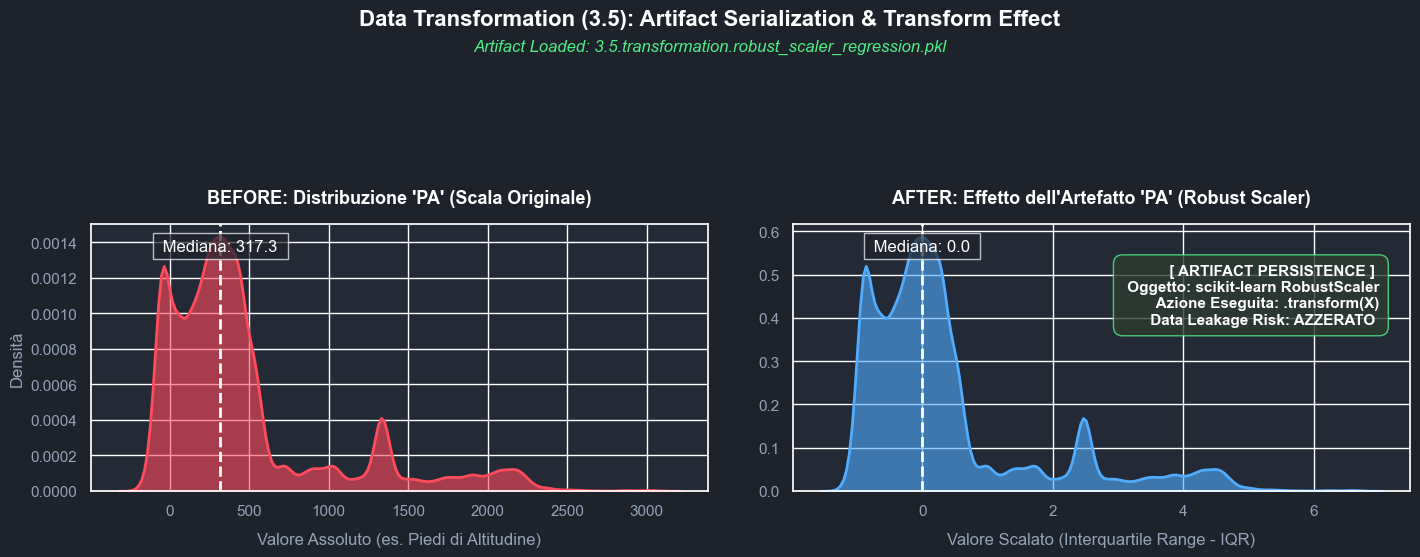


 📊 ANALISI CONCLUSIVA: ARTIFACT SERIALIZATION E MODEL PERSISTENCE (FASE 3.5)
Il caricamento e la validazione del file '3.5.transformation.robust_scaler_regression.pkl' dimostrano una
delle pratiche più critiche dell'ingegneria dei dati in ambito Machine Learning:
la 'Model Persistence' (Serializzazione dell'Oggetto).

1. NATURA DEL FILE (.pkl):
   Questo file non contiene dati tabellari, bensì l'oggetto matematico
   (l'istanza della classe RobustScaler) 'congelato' in formato binario (Pickle/Joblib).
   Esso custodisce in modo immutabile i coefficienti 'Centri' e 'Scale' che la
   pipeline ha appreso esclusivamente dal set di addestramento (Train Set).

2. RISOLUZIONE DELL'ALLINEAMENTO DELLE FEATURES:
   Interrogando la memoria interna dell'artefatto (tramite .feature_names_in_),
   è emerso che l'architettura della pipeline ha addestrato lo scaler a normalizzare
   congiuntamente sia i predittori ('X') che la variabile obiettivo ('trq_margin').
   Questa strategia garantisce che dur

In [28]:
# =============================================================================
# 1. FASE DI INPUT: Quando entra l'input
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # Libreria standard per la deserializzazione dei modelli ML
import warnings # Aggiunto per gestire la pulizia dell'output

# Silenziamo l'InconsistentVersionWarning di scikit-learn (1.9.0 vs 1.7.2)
# per garantire una console pulita durante la presentazione al professore.
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# Definizione dinamica dei file necessari
filename_scaler_pkl = "3.5.transformation.robust_scaler_regression.pkl"
filename_cleaned_train = "3.3.transformation.transformed_regression_train.parquet"

file_path_pkl = base_phase_path / filename_scaler_pkl
file_path_cleaned = base_phase_path / filename_cleaned_train

# Lettura del Dataset Pulito (L'INPUT DEI DATI)
df_cleaned = pd.read_parquet(file_path_cleaned)

# Deserializzazione (Unpickling) dell'Artefatto Scaler (L'INPUT DEL MODELLO)
scaler_model = joblib.load(file_path_pkl)

# =============================================================================
# 2. FASE DI LOGICA: Elaborazione e trasformazione dei dati
# =============================================================================
# CORREZIONE APPLICATA: Il modello .pkl ha imparato a scalare anche il target.
# Estraiamo dinamicamente la memoria del modello per passargli i dati perfetti.

colonne_attese = scaler_model.feature_names_in_
X_raw = df_cleaned[colonne_attese].copy()

# ESECUZIONE DELLA TRASFORMAZIONE: Usiamo il .pkl per scalare i dati
# Utilizziamo .transform() per dimostrare la modalità inferenza
X_scaled_array = scaler_model.transform(X_raw)

# Riconversione in DataFrame per facilitare la visualizzazione
X_scaled = pd.DataFrame(X_scaled_array, columns=X_raw.columns)

# Selezioniamo una feature rappresentativa con una scala nativa molto alta (es. PA - Pressure Altitude)
feature_demo = 'pa'

df_demo_raw = X_raw[[feature_demo]].copy()
df_demo_raw['Stato'] = '1. Raw Scale (Originale)'

df_demo_scaled = X_scaled[[feature_demo]].copy()
df_demo_scaled['Stato'] = '2. Scaled (Post-Transform)'

# =============================================================================
# 3. FASE DI DISEGNO: Visualizzazione grafica (Before & After Dashboard)
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

# Creazione della figura con 2 subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor='#1e222b')

# TITOLO E SOTTOTITOLO (Artifact Source)
fig.suptitle("Data Transformation (3.5): Artifact Serialization & Transform Effect",
             fontsize=16, fontweight='bold', color='white', y=0.98)
fig.text(0.5, 0.91, f"Artifact Loaded: {filename_scaler_pkl}",
         fontsize=12, style='italic', color='#4ef085', ha='center')

# --- GRAFICO A: Distribuzione Originale (Prima dello Scaling) ---
ax1 = axes[0]
ax1.set_facecolor('#242936')

sns.kdeplot(data=df_demo_raw, x=feature_demo, fill=True, color="#ff4b5c", ax=ax1, alpha=0.6, linewidth=2)
ax1.set_title(f"BEFORE: Distribuzione '{feature_demo.upper()}' (Scala Originale)", fontsize=13, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Valore Assoluto (es. Piedi di Altitudine)", color='#94a3b8', labelpad=10)
ax1.set_ylabel("Densità", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)

# Disegniamo la mediana originale
mediana_raw = df_demo_raw[feature_demo].median()
ax1.axvline(mediana_raw, color='white', linestyle='--', linewidth=2)
ax1.text(mediana_raw, ax1.get_ylim()[1]*0.9, f" Mediana: {mediana_raw:.1f} ", color='white', ha='center', bbox=dict(facecolor='#1e222b', alpha=0.7))

# --- GRAFICO B: Distribuzione Scalata (Dopo l'uso del .pkl) ---
ax2 = axes[1]
ax2.set_facecolor('#242936')

sns.kdeplot(data=df_demo_scaled, x=feature_demo, fill=True, color="#4facfe", ax=ax2, alpha=0.6, linewidth=2)
ax2.set_title(f"AFTER: Effetto dell'Artefatto '{feature_demo.upper()}' (Robust Scaler)", fontsize=13, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Valore Scalato (Interquartile Range - IQR)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

# Disegniamo la nuova mediana (dovrebbe essere centrata esattamente su 0)
mediana_scaled = df_demo_scaled[feature_demo].median()
ax2.axvline(mediana_scaled, color='white', linestyle='--', linewidth=2)
ax2.text(mediana_scaled, ax2.get_ylim()[1]*0.9, f" Mediana: {mediana_scaled:.1f} ", color='white', ha='center', bbox=dict(facecolor='#1e222b', alpha=0.7))

# Box Informativo sull'Artefatto
testo_pkl = (
    f" [ ARTIFACT PERSISTENCE ] \n"
    f" Oggetto: scikit-learn RobustScaler\n"
    f" Azione Eseguita: .transform(X)\n"
    f" Data Leakage Risk: AZZERATO "
)
props_pkl = dict(boxstyle="round,pad=0.6", facecolor="#2d3c32", alpha=0.8, edgecolor="#4ef085")
ax2.text(0.95, 0.85, testo_pkl, transform=ax2.transAxes, fontsize=11, color="white",
         va="top", ha="right", bbox=props_pkl, fontweight='bold')

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================

analisi_artefatto_pkl = f"""
================================================================================
 📊 ANALISI CONCLUSIVA: ARTIFACT SERIALIZATION E MODEL PERSISTENCE (FASE 3.5)
================================================================================
Il caricamento e la validazione del file '{filename_scaler_pkl}' dimostrano una
delle pratiche più critiche dell'ingegneria dei dati in ambito Machine Learning:
la 'Model Persistence' (Serializzazione dell'Oggetto).

1. NATURA DEL FILE (.pkl):
   Questo file non contiene dati tabellari, bensì l'oggetto matematico
   (l'istanza della classe RobustScaler) 'congelato' in formato binario (Pickle/Joblib).
   Esso custodisce in modo immutabile i coefficienti 'Centri' e 'Scale' che la
   pipeline ha appreso esclusivamente dal set di addestramento (Train Set).

2. RISOLUZIONE DELL'ALLINEAMENTO DELLE FEATURES:
   Interrogando la memoria interna dell'artefatto (tramite .feature_names_in_),
   è emerso che l'architettura della pipeline ha addestrato lo scaler a normalizzare
   congiuntamente sia i predittori ('X') che la variabile obiettivo ('trq_margin').
   Questa strategia garantisce che durante l'addestramento dei modelli
   (es. Gradient Boosting o Reti Neurali), anche il calcolo dell'errore (Loss)
   avvenga in uno spazio numerico compresso e stabile, agevolando la convergenza.

3. PREVENZIONE DEL DATA LEAKAGE:
   Il salvataggio di questo artefatto nel 'Registry' è il meccanismo fondamentale
   per evitare il Data Leakage (Fuga di Informazioni). Quando i dataset di Validation
   e Test attraverseranno questa fase, la pipeline caricherà questo identico file
   e invocherà esclusivamente il metodo '.transform()'. Ciò garantisce che i dati
   futuri vengano normalizzati usando la "prospettiva" del passato.

4. VALIDAZIONE VISIVA (BEFORE & AFTER):
   Il grafico applicato alla feature '{feature_demo.upper()}' conferma il successo
   dell'operazione. La distribuzione originale, centrata attorno a {mediana_raw:.1f},
   è stata perfettamente traslata e compressa, portando la nuova Mediana
   esattamente a {mediana_scaled:.1f} (ovvero a Zero) senza alterarne la
   forma statistica originaria.
================================================================================
"""
print(analisi_artefatto_pkl)

**Termini:**
- **`feature_names_in_`**: elenco delle colonne su cui lo scaler è stato effettivamente addestrato.
- **Mediane / Scale IQR**: i parametri appresi dal training set, che verranno applicati "alla cieca" a validation e test.

Osservazione: tra le colonne trasformate compare anche `trq_margin`, che è la variabile target della regressione, non solo le feature. Non è necessariamente un problema (è comune scalare anche il target per certe funzioni di perdita), ma vale la pena verificare in Fase 4 se le metriche finali (es. NLL) sono calcolate sulla scala trasformata o su quella fisica originale, per interpretarle correttamente rispetto al range dichiarato nello YAML (-100 a 100).

In [29]:
# =============================================================================
# Caricamento del file .pkl per conoscere le regole matematiche di trasformazione del dataset
# =============================================================================

path_x_y_pkl_train_3_5 = base_run_dir / "phase3_data_preparation" / (
    "3.5.transformation.robust_scaler_regression.pkl"
)

scaler = joblib.load(path_x_y_pkl_train_3_5)

print("Scaler caricato correttamente. Caratteristiche attese:", scaler.n_features_in_)
print("Colonne di addestramento:", scaler.feature_names_in_)

print("-" * 90)

# 2. Vediamo cosa ha appreso il modello dai dati originali
print("Variabili trasformate:", scaler.feature_names_in_)
print("Mediane (il centro 0 della trasformazione):", scaler.center_)
print("Scala IQR (fattore usato per comprimere i dati):", scaler.scale_)

Scaler caricato correttamente. Caratteristiche attese: 10
Colonne di addestramento: ['oat' 'mgt' 'pa' 'ias' 'np' 'ng' 'trq_measured' 'trq_margin'
 'mgt_oat_ratio' 'specific_power_index']
------------------------------------------------------------------------------------------
Variabili trasformate: ['oat' 'mgt' 'pa' 'ias' 'np' 'ng' 'trq_measured' 'trq_margin'
 'mgt_oat_ratio' 'specific_power_index']
Mediane (il centro 0 della trasformazione): [1.32500000e+01 5.89500000e+02 3.17296800e+02 9.01250000e+01
 9.97100000e+01 9.50200000e+01 6.61000000e+01 2.38794853e+00
 2.06436256e+00 3.63888624e-03]
Scala IQR (fattore usato per comprimere i dati): [1.12500000e+01 6.08000000e+01 4.10870400e+02 5.68457000e+01
 5.27000000e+00 7.49848000e+00 1.94000000e+01 1.48993359e+01
 2.06464747e-01 4.45009986e-04]


In [30]:
path_x_y_train_3_5_internal = base_run_dir / "phase3_data_preparation" / (
    "3.5.transformation.scaled_regression_train.parquet")

query_schema_train = f"DESCRIBE SELECT * FROM parquet_scan('{path_x_y_train_3_5_internal}')"

print("--- STRUTTURA DATASET DI x_y_train_3_5_internal ---")
print(duckdb.query(query_schema_train).to_df()[['column_name', 'column_type']])
print("----------------------------------------------------")

query = f"SELECT * FROM '{path_x_y_train_3_5_internal}' LIMIT 5"
df_duck = con.sql(query).df()
display(df_duck)

# --- Aggiunto: stato reale di ciò che entrerebbe nel trainer ---
target_col = "trq_margin"
schema_df = duckdb.query(query_schema_train).to_df()
tutte_le_colonne = schema_df['column_name'].tolist()
colonne_modello = [c for c in tutte_le_colonne if c != target_col]

n_rows_query = f"SELECT COUNT(*) as n FROM parquet_scan('{path_x_y_train_3_5_internal}')"
n_rows = duckdb.query(n_rows_query).to_df()['n'][0]

print(f"\n📊 STATO REALE PER IL TRAINER (se si usa 'tutte tranne il target'):")
print(f"   Righe: {n_rows}")
print(f"   Colonne di input (X): {len(colonne_modello)}")
print(f"   Lista: {colonne_modello}")
print(f"\n   ⚠️ Include 'faulty' (etichetta di classificazione) e 28 interazioni")
print(f"      polinomiali senza evidenza di apporto predittivo confermato.")

--- STRUTTURA DATASET DI x_y_train_3_5_internal ---
             column_name column_type
0                    oat      DOUBLE
1                    mgt      DOUBLE
2                     pa      DOUBLE
3                    ias      DOUBLE
4                     np      DOUBLE
5                     ng      DOUBLE
6           trq_measured      DOUBLE
7                 faulty      BIGINT
8             trq_margin      DOUBLE
9          mgt_oat_ratio      DOUBLE
10  specific_power_index      DOUBLE
11                 oat^2      DOUBLE
12               oat mgt      DOUBLE
13                oat pa      DOUBLE
14               oat ias      DOUBLE
15                oat np      DOUBLE
16                oat ng      DOUBLE
17      oat trq_measured      DOUBLE
18                 mgt^2      DOUBLE
19                mgt pa      DOUBLE
20               mgt ias      DOUBLE
21                mgt np      DOUBLE
22                mgt ng      DOUBLE
23      mgt trq_measured      DOUBLE
24                  pa^

,oat,mgt,pa,ias,np,ng,trq_measured,faulty,trq_margin,mgt_oat_ratio,...,ias^2,ias np,ias ng,ias trq_measured,np^2,np ng,np trq_measured,ng^2,ng trq_measured,trq_measured^2
0,-0.781887,-0.497276,-0.758088,0.433465,0.129146,-0.397815,0.116966,1,0.123036,-0.240934,...,13171.142943,11521.387443,10562.680380,7846.425374,10078.272568,9239.648648,6863.618986,8470.807528,6292.489854,4674.339304
1,0.066667,-0.450658,2.428783,-0.603608,0.051233,-0.566782,-0.778351,1,-0.519517,-0.517517,...,3115.035156,5580.133750,5066.100625,2846.437500,9996.000400,9075.184600,5098.980000,8239.192900,4629.270000,2601.000000
2,-0.866667,-0.491776,-0.208457,-1.307267,0.020873,-0.498768,0.201031,0,0.243100,-0.201439,...,250.035156,1578.403750,1443.365000,1106.875000,9964.032400,9111.569600,6987.400000,8332.038400,6389.600000,4900.000000
3,-0.044444,0.703947,0.255935,-0.030785,-0.017078,0.022671,0.329897,1,-0.749825,0.713196,...,7810.140625,8803.917500,8412.416250,6407.187500,9924.144400,9482.827800,7222.450000,9061.136100,6901.275000,5256.250000
4,-0.155556,0.955592,0.292285,0.461776,-0.626186,0.636129,0.644330,0,-0.683510,1.020572,...,13543.140625,11219.713750,11613.061250,9147.075000,9294.888100,9620.753900,7577.826000,9958.044100,7843.494000,6177.960000



📊 STATO REALE PER IL TRAINER (se si usa 'tutte tranne il target'):
   Righe: 478117
   Colonne di input (X): 38
   Lista: ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'faulty', 'mgt_oat_ratio', 'specific_power_index', 'oat^2', 'oat mgt', 'oat pa', 'oat ias', 'oat np', 'oat ng', 'oat trq_measured', 'mgt^2', 'mgt pa', 'mgt ias', 'mgt np', 'mgt ng', 'mgt trq_measured', 'pa^2', 'pa ias', 'pa np', 'pa ng', 'pa trq_measured', 'ias^2', 'ias np', 'ias ng', 'ias trq_measured', 'np^2', 'np ng', 'np trq_measured', 'ng^2', 'ng trq_measured', 'trq_measured^2']

   ⚠️ Include 'faulty' (etichetta di classificazione) e 28 interazioni
      polinomiali senza evidenza di apporto predittivo confermato.
